# Benchmarking Python Caching Backends for `fedfred`

This notebook benchmarks caching strategies relevant to `fedfred` v4.

The benchmark is separated into three layers:

1. **Application-level caching** — caches Python objects or serialized API payloads after a request has been made.
   - `cachetools`
   - `diskcache`
   - `cacheout`

2. **Transport-level HTTP caching** — caches HTTP responses at the client/transport layer.
   - `hishel` for `httpx`
   - `requests-cache` for `requests`

3. **Cross-layer comparison** — compares transport-level HTTP caching against application-level response caching under API-shaped workloads.

The notebook uses a deterministic local HTTP server rather than the live FRED API. This avoids rate limits, API-key requirements, external network jitter, and non-reproducibility while preserving the benchmarking structure needed for FRED-like request caching.


## Benchmark design

The goal is not to crown a universal fastest package. The goal is to identify which backend is appropriate for each role in `fedfred`:

| Layer | Candidate | Intended role |
|---|---|---|
| Application memory cache | `cachetools`, `cacheout` | Fast request-result caching inside a Python process |
| Application persistent cache | `diskcache` | Optional notebook/research cache that survives restarts |
| HTTP transport cache | `hishel`, `requests-cache` | Cache-aware HTTP client behavior based on HTTP semantics |

The notebook measures:

- write latency
- hit latency
- miss latency
- mixed workload latency
- eviction behavior
- TTL expiration behavior
- memory footprint
- threaded throughput
- restart persistence
- HTTP origin-hit reduction
- transport-cache latency
- application-level vs transport-level caching performance


## Optional installation cell

Run this cell if your environment does not already include the benchmark dependencies.


In [1]:
%pip install -q cachetools diskcache cacheout requests-cache hishel httpx pandas matplotlib psutil


Note: you may need to restart the kernel to use updated packages.


## Imports and global configuration


In [2]:
from __future__ import annotations

import contextlib
import dataclasses
import gc
import hashlib
import json
import math
import os
import pickle
import random
import shutil
import statistics
import tempfile
import threading
import time
import tracemalloc
import urllib.parse
from collections import Counter
from concurrent.futures import ThreadPoolExecutor, as_completed
from dataclasses import dataclass
from functools import lru_cache
from http.server import BaseHTTPRequestHandler, ThreadingHTTPServer
from pathlib import Path
from time import perf_counter, perf_counter_ns
from typing import Any, Callable, Dict, Hashable, Iterable, Iterator, List, Mapping, MutableMapping, Optional, Protocol, Sequence, Tuple

import matplotlib.pyplot as plt
import pandas as pd

try:
    import psutil
except Exception:  # pragma: no cover
    psutil = None

try:
    import cachetools
except Exception:  # pragma: no cover
    cachetools = None

try:
    import diskcache
except Exception:  # pragma: no cover
    diskcache = None

try:
    import cacheout
except Exception:  # pragma: no cover
    cacheout = None

try:
    import httpx
except Exception:  # pragma: no cover
    httpx = None

try:
    import requests
except Exception:  # pragma: no cover
    requests = None

try:
    import requests_cache
except Exception:  # pragma: no cover
    requests_cache = None

try:
    import hishel
except Exception:  # pragma: no cover
    hishel = None

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

RANDOM_SEED = 42
random.seed(RANDOM_SEED)

RESULTS_DIR = Path("benchmark_results")
FIGURES_DIR = RESULTS_DIR / "figures"
RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

N_RUNS = 10
N_KEYS = 2_000
CACHE_MAXSIZE = 512
TTL_SECONDS = 1.0
THREAD_WORKERS = min(8, os.cpu_count() or 4)

PAYLOAD_SIZES = {
    "small_metadata": 10,
    "medium_series": 500,
    "large_series": 5_000,
}

print(f"Results directory: {RESULTS_DIR.resolve()}")
print(f"Figures directory: {FIGURES_DIR.resolve()}")


Results directory: /Users/nikhilsunder/Documents/Github/Python Packages/fedfred/benchmarks/benchmark_results
Figures directory: /Users/nikhilsunder/Documents/Github/Python Packages/fedfred/benchmarks/benchmark_results/figures


## Utility functions

These helpers provide repeatable timing, payload generation, basic memory measurement, and plotting.


In [3]:
def now_ns() -> int:
    return perf_counter_ns()


def ns_to_us(ns: float) -> float:
    return ns / 1_000.0


def ns_to_ms(ns: float) -> float:
    return ns / 1_000_000.0


def safe_import_status() -> pd.DataFrame:
    rows = [
        ("cachetools", cachetools is not None),
        ("diskcache", diskcache is not None),
        ("cacheout", cacheout is not None),
        ("httpx", httpx is not None),
        ("requests", requests is not None),
        ("requests-cache", requests_cache is not None),
        ("hishel", hishel is not None),
        ("psutil", psutil is not None),
    ]
    return pd.DataFrame(rows, columns=["package", "available"])


def get_process_rss_mb() -> float | None:
    if psutil is None:
        return None
    return psutil.Process(os.getpid()).memory_info().rss / (1024 ** 2)


def make_cache_key(service: str, endpoint: str, params: Mapping[str, Any]) -> tuple[str, str, tuple[tuple[str, Any], ...]]:
    return (service, endpoint, tuple(sorted(params.items())))


def make_fred_like_payload(series_id: str, n_obs: int) -> dict[str, Any]:
    observations = []
    base = 100.0 + (abs(hash(series_id)) % 50)
    for i in range(n_obs):
        year = 1990 + (i // 365)
        month = ((i // 30) % 12) + 1
        day = (i % 28) + 1
        value = base + math.sin(i / 31.0) * 2.0 + i * 0.001
        observations.append(
            {
                "realtime_start": "2026-05-02",
                "realtime_end": "2026-05-02",
                "date": f"{year:04d}-{month:02d}-{day:02d}",
                "value": f"{value:.4f}",
            }
        )
    return {
        "realtime_start": "2026-05-02",
        "realtime_end": "2026-05-02",
        "observation_start": "1990-01-01",
        "observation_end": "2026-05-02",
        "units": "lin",
        "output_type": 1,
        "file_type": "json",
        "order_by": "observation_date",
        "sort_order": "asc",
        "count": len(observations),
        "offset": 0,
        "limit": 100000,
        "series_id": series_id,
        "observations": observations,
    }


def make_workload_keys(n_keys: int) -> list[Hashable]:
    series_ids = ["DGS10", "UNRATE", "CPIAUCSL", "FEDFUNDS", "PAYEMS", "GDPC1", "PCE", "INDPRO", "M2SL", "HOUST"]
    keys: list[Hashable] = []
    for i in range(n_keys):
        params = {
            "series_id": series_ids[i % len(series_ids)],
            "observation_start": f"{1990 + (i % 25)}-01-01",
            "frequency": "d" if i % 2 == 0 else "m",
            "units": "lin",
            "vintage": f"{2000 + (i % 24)}-01-01",
        }
        keys.append(make_cache_key("fred", "series/observations", params))
    return keys


def summarize_latencies(values_ns: Sequence[int | float]) -> dict[str, float]:
    if not values_ns:
        return {"mean_us": math.nan, "median_us": math.nan, "p95_us": math.nan, "min_us": math.nan, "max_us": math.nan}
    vals = sorted(float(v) for v in values_ns)
    p95_index = min(len(vals) - 1, int(math.ceil(0.95 * len(vals))) - 1)
    return {
        "mean_us": ns_to_us(statistics.mean(vals)),
        "median_us": ns_to_us(statistics.median(vals)),
        "p95_us": ns_to_us(vals[p95_index]),
        "min_us": ns_to_us(vals[0]),
        "max_us": ns_to_us(vals[-1]),
    }


def barplot(df: pd.DataFrame, x: str, y: str, title: str, ylabel: str, filename: str, sort: bool = True) -> None:
    plot_df = df.copy()
    if sort:
        plot_df = plot_df.sort_values(y)
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.bar(plot_df[x].astype(str), plot_df[y])
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel(x)
    ax.tick_params(axis="x", rotation=35)
    fig.tight_layout()
    out = FIGURES_DIR / filename
    fig.savefig(out, dpi=160)
    plt.show()
    print(f"Saved figure: {out}")

safe_import_status()


,package,available
0,cachetools,True
1,diskcache,True
2,cacheout,True
3,httpx,True
4,requests,True
5,requests-cache,True
6,hishel,True
7,psutil,True


## Cache backend abstraction

The wrapper below gives `cachetools`, `diskcache`, and `cacheout` the same minimal interface.

This mirrors the kind of protocol `fedfred` should eventually expose internally.


In [4]:
_MISSING = object()

class CacheBackend(Protocol):
    name: str

    def get(self, key: Hashable, default: Any = _MISSING) -> Any: ...
    def set(self, key: Hashable, value: Any) -> None: ...
    def delete(self, key: Hashable) -> None: ...
    def clear(self) -> None: ...
    def close(self) -> None: ...


class CachetoolsBackend:
    def __init__(self, maxsize: int = CACHE_MAXSIZE, ttl: float | None = None) -> None:
        if cachetools is None:
            raise ImportError("cachetools is not installed")
        self.name = "cachetools_ttl" if ttl is not None else "cachetools_lru"
        self.cache = cachetools.TTLCache(maxsize=maxsize, ttl=ttl) if ttl is not None else cachetools.LRUCache(maxsize=maxsize)
        self._lock = threading.RLock()

    def get(self, key: Hashable, default: Any = _MISSING) -> Any:
        with self._lock:
            return self.cache.get(key, default)

    def set(self, key: Hashable, value: Any) -> None:
        with self._lock:
            self.cache[key] = value

    def delete(self, key: Hashable) -> None:
        with self._lock:
            self.cache.pop(key, None)

    def clear(self) -> None:
        with self._lock:
            self.cache.clear()

    def close(self) -> None:
        self.clear()


class DiskCacheBackend:
    def __init__(self, maxsize: int = CACHE_MAXSIZE, directory: str | Path | None = None, ttl: float | None = None) -> None:
        if diskcache is None:
            raise ImportError("diskcache is not installed")
        self.name = "diskcache"
        self.directory = Path(directory) if directory is not None else Path(tempfile.mkdtemp(prefix="fedfred_diskcache_"))
        self.ttl = ttl
        self.cache = diskcache.Cache(str(self.directory), size_limit=maxsize * 1024 * 1024)

    def get(self, key: Hashable, default: Any = _MISSING) -> Any:
        return self.cache.get(key, default=default)

    def set(self, key: Hashable, value: Any) -> None:
        self.cache.set(key, value, expire=self.ttl)

    def delete(self, key: Hashable) -> None:
        self.cache.delete(key)

    def clear(self) -> None:
        self.cache.clear()

    def close(self) -> None:
        self.cache.close()
        shutil.rmtree(self.directory, ignore_errors=True)


class CacheoutBackend:
    def __init__(self, maxsize: int = CACHE_MAXSIZE, ttl: float | None = None) -> None:
        if cacheout is None:
            raise ImportError("cacheout is not installed")
        self.name = "cacheout"
        self.cache = cacheout.Cache(maxsize=maxsize, ttl=0 if ttl is None else ttl)

    def get(self, key: Hashable, default: Any = _MISSING) -> Any:
        value = self.cache.get(key)
        if value is None:
            return default
        return value

    def set(self, key: Hashable, value: Any) -> None:
        self.cache.set(key, value)

    def delete(self, key: Hashable) -> None:
        self.cache.delete(key)

    def clear(self) -> None:
        self.cache.clear()

    def close(self) -> None:
        self.clear()


@contextlib.contextmanager
def managed_backend(kind: str, *, maxsize: int = CACHE_MAXSIZE, ttl: float | None = None) -> Iterator[CacheBackend]:
    backend: CacheBackend
    if kind == "cachetools_lru":
        backend = CachetoolsBackend(maxsize=maxsize, ttl=None)
    elif kind == "cachetools_ttl":
        backend = CachetoolsBackend(maxsize=maxsize, ttl=TTL_SECONDS if ttl is None else ttl)
    elif kind == "diskcache":
        backend = DiskCacheBackend(maxsize=maxsize, ttl=ttl)
    elif kind == "cacheout":
        backend = CacheoutBackend(maxsize=maxsize, ttl=ttl)
    else:
        raise ValueError(f"Unknown backend kind: {kind}")
    try:
        yield backend
    finally:
        backend.close()


APPLICATION_BACKENDS = [
    kind for kind, available in [
        ("cachetools_lru", cachetools is not None),
        ("cachetools_ttl", cachetools is not None),
        ("diskcache", diskcache is not None),
        ("cacheout", cacheout is not None),
    ] if available
]

APPLICATION_BACKENDS


['cachetools_lru', 'cachetools_ttl', 'diskcache', 'cacheout']

## Application-level microbenchmarks

This section benchmarks direct cache operations independently from HTTP.

Each backend receives the same FRED-shaped keys and payloads.


In [5]:
def benchmark_set_get_miss(
    backend_kind: str,
    payload_name: str,
    n_obs: int,
    n_keys: int = N_KEYS,
    n_runs: int = N_RUNS,
) -> list[dict[str, Any]]:
    rows: list[dict[str, Any]] = []
    keys = make_workload_keys(n_keys)
    payload = make_fred_like_payload("DGS10", n_obs)
    payload_bytes = len(pickle.dumps(payload, protocol=pickle.HIGHEST_PROTOCOL))

    for run in range(n_runs):
        gc.collect()
        rss_before = get_process_rss_mb()
        with managed_backend(backend_kind, maxsize=CACHE_MAXSIZE) as cache:
            set_times = []
            hit_times = []
            miss_times = []

            for key in keys:
                t0 = now_ns()
                cache.set(key, payload)
                set_times.append(now_ns() - t0)

            for key in keys[:CACHE_MAXSIZE]:
                t0 = now_ns()
                _ = cache.get(key, _MISSING)
                hit_times.append(now_ns() - t0)

            for i in range(CACHE_MAXSIZE):
                miss_key = ("missing", i)
                t0 = now_ns()
                _ = cache.get(miss_key, _MISSING)
                miss_times.append(now_ns() - t0)

        rss_after = get_process_rss_mb()

        for op_name, values in [("set", set_times), ("hit", hit_times), ("miss", miss_times)]:
            summary = summarize_latencies(values)
            rows.append({
                "backend": backend_kind,
                "payload": payload_name,
                "run": run,
                "operation": op_name,
                "n_obs": n_obs,
                "n_keys": n_keys,
                "payload_pickle_bytes": payload_bytes,
                "rss_delta_mb": None if rss_before is None or rss_after is None else rss_after - rss_before,
                **summary,
            })
    return rows


micro_rows: list[dict[str, Any]] = []
for backend in APPLICATION_BACKENDS:
    for payload_name, n_obs in PAYLOAD_SIZES.items():
        print(f"Running microbenchmark: backend={backend}, payload={payload_name}")
        micro_rows.extend(benchmark_set_get_miss(backend, payload_name, n_obs))

micro_df = pd.DataFrame(micro_rows)
micro_df.to_csv(RESULTS_DIR / "application_cache_microbenchmarks.csv", index=False)
micro_df.head()


Running microbenchmark: backend=cachetools_lru, payload=small_metadata
Running microbenchmark: backend=cachetools_lru, payload=medium_series
Running microbenchmark: backend=cachetools_lru, payload=large_series
Running microbenchmark: backend=cachetools_ttl, payload=small_metadata
Running microbenchmark: backend=cachetools_ttl, payload=medium_series
Running microbenchmark: backend=cachetools_ttl, payload=large_series
Running microbenchmark: backend=diskcache, payload=small_metadata
Running microbenchmark: backend=diskcache, payload=medium_series
Running microbenchmark: backend=diskcache, payload=large_series
Running microbenchmark: backend=cacheout, payload=small_metadata
Running microbenchmark: backend=cacheout, payload=medium_series
Running microbenchmark: backend=cacheout, payload=large_series


,backend,payload,run,operation,n_obs,n_keys,payload_pickle_bytes,rss_delta_mb,mean_us,median_us,p95_us,min_us,max_us
0,cachetools_lru,small_metadata,0,set,10,2000,698,0.109375,1.503055,1.458,1.917,0.666,58.958
1,cachetools_lru,small_metadata,0,hit,10,2000,698,0.109375,0.677957,0.708,0.875,0.208,4.000
2,cachetools_lru,small_metadata,0,miss,10,2000,698,0.109375,0.278127,0.250,0.375,0.208,0.625
3,cachetools_lru,small_metadata,1,set,10,2000,698,0.000000,1.369472,1.375,1.875,0.666,26.625
4,cachetools_lru,small_metadata,1,hit,10,2000,698,0.000000,0.671188,0.708,0.875,0.208,3.666


In [6]:
micro_summary = (
    micro_df
    .groupby(["backend", "payload", "operation"], as_index=False)
    .agg(
        mean_us=("mean_us", "mean"),
        median_us=("median_us", "mean"),
        p95_us=("p95_us", "mean"),
        rss_delta_mb=("rss_delta_mb", "mean"),
        payload_pickle_bytes=("payload_pickle_bytes", "first"),
    )
)

micro_summary.to_csv(RESULTS_DIR / "application_cache_microbenchmark_summary.csv", index=False)
micro_summary


,backend,payload,operation,mean_us,median_us,p95_us,rss_delta_mb,payload_pickle_bytes
0,cacheout,large_series,hit,0.703239,0.70810,0.8294,0.000000,200334
1,cacheout,large_series,miss,0.442279,0.44160,0.4877,0.000000,200334
2,cacheout,large_series,set,1.966882,2.14140,2.4417,0.000000,200334
3,cacheout,medium_series,hit,0.696065,0.70800,0.8334,0.000000,20299
4,cacheout,medium_series,miss,0.461147,0.45810,0.5376,0.000000,20299
5,cacheout,medium_series,set,1.979319,2.13740,2.5917,0.000000,20299
6,cacheout,small_metadata,hit,0.711549,0.70390,0.8543,0.000000,698
7,cacheout,small_metadata,miss,0.437653,0.43740,0.5041,0.000000,698
8,cacheout,small_metadata,set,1.987307,2.15820,2.5705,0.000000,698
9,cachetools_lru,large_series,hit,0.785464,0.76660,1.0873,0.000000,200334


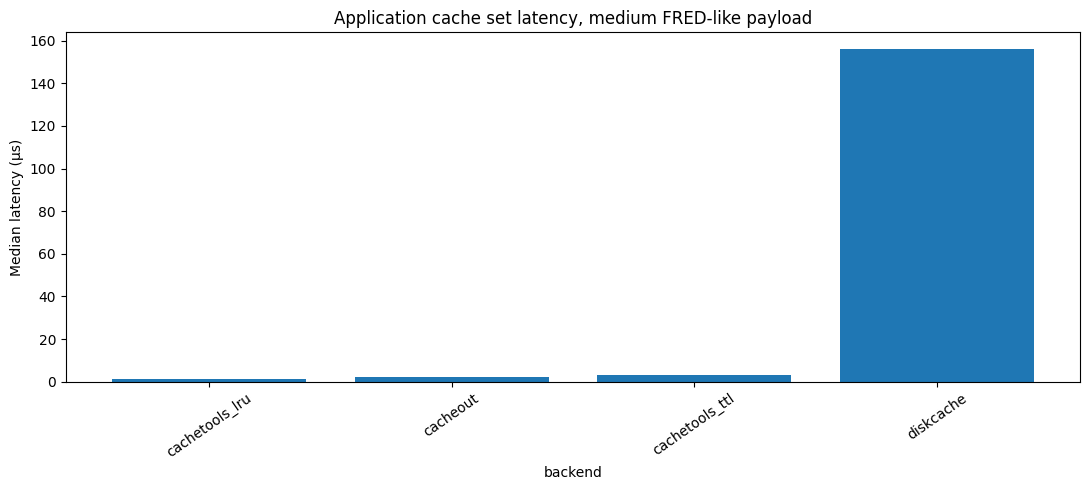

Saved figure: benchmark_results/figures/application_cache_set_median_latency.png


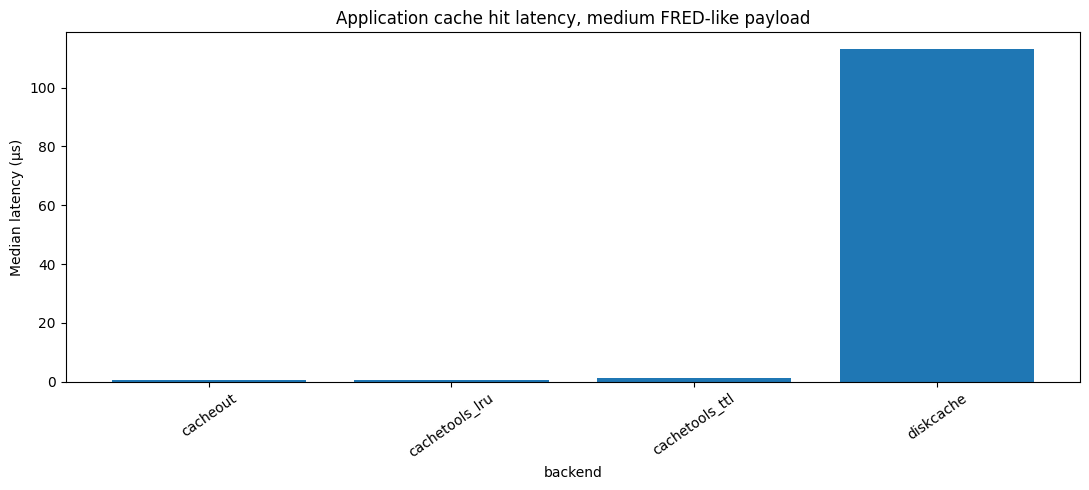

Saved figure: benchmark_results/figures/application_cache_hit_median_latency.png


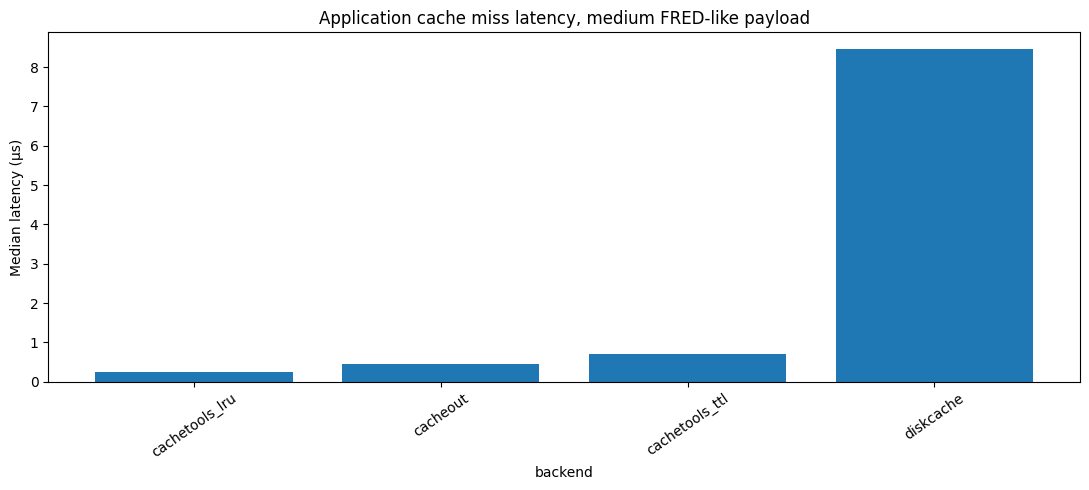

Saved figure: benchmark_results/figures/application_cache_miss_median_latency.png


In [7]:
for operation in ["set", "hit", "miss"]:
    plot_df = micro_summary[(micro_summary["operation"] == operation) & (micro_summary["payload"] == "medium_series")]
    barplot(
        plot_df,
        x="backend",
        y="median_us",
        title=f"Application cache {operation} latency, medium FRED-like payload",
        ylabel="Median latency (µs)",
        filename=f"application_cache_{operation}_median_latency.png",
    )


## Mixed workload and eviction-pressure benchmark

This workload approximates repeated data access in notebooks:

- 80% requests target hot keys already in cache.
- 20% requests introduce cold keys.
- total key cardinality exceeds cache capacity, forcing evictions for bounded in-memory caches.


In [8]:
def benchmark_mixed_workload(
    backend_kind: str,
    payload_name: str,
    n_obs: int,
    n_operations: int = 10_000,
    hot_key_count: int = 128,
    cold_key_count: int = 4_000,
    hit_probability: float = 0.80,
    n_runs: int = N_RUNS,
) -> list[dict[str, Any]]:
    rows = []
    hot_keys = make_workload_keys(hot_key_count)
    cold_keys = make_workload_keys(cold_key_count)
    payload = make_fred_like_payload("DGS10", n_obs)

    for run in range(n_runs):
        random.seed(RANDOM_SEED + run)
        with managed_backend(backend_kind, maxsize=CACHE_MAXSIZE) as cache:
            for key in hot_keys:
                cache.set(key, payload)

            latencies = []
            hits = 0
            misses = 0
            writes = 0

            for i in range(n_operations):
                use_hot = random.random() < hit_probability
                key = random.choice(hot_keys) if use_hot else random.choice(cold_keys)

                t0 = now_ns()
                value = cache.get(key, _MISSING)
                if value is _MISSING:
                    misses += 1
                    cache.set(key, payload)
                    writes += 1
                else:
                    hits += 1
                latencies.append(now_ns() - t0)

            summary = summarize_latencies(latencies)
            rows.append({
                "backend": backend_kind,
                "payload": payload_name,
                "run": run,
                "n_operations": n_operations,
                "hot_key_count": hot_key_count,
                "cold_key_count": cold_key_count,
                "hit_probability_target": hit_probability,
                "actual_hit_rate": hits / n_operations,
                "actual_miss_rate": misses / n_operations,
                "writes": writes,
                **summary,
            })
    return rows


mixed_rows = []
for backend in APPLICATION_BACKENDS:
    for payload_name, n_obs in PAYLOAD_SIZES.items():
        print(f"Running mixed workload: backend={backend}, payload={payload_name}")
        mixed_rows.extend(benchmark_mixed_workload(backend, payload_name, n_obs))

mixed_df = pd.DataFrame(mixed_rows)
mixed_df.to_csv(RESULTS_DIR / "application_cache_mixed_workload.csv", index=False)
mixed_summary = mixed_df.groupby(["backend", "payload"], as_index=False).agg(
    median_us=("median_us", "mean"),
    p95_us=("p95_us", "mean"),
    hit_rate=("actual_hit_rate", "mean"),
    miss_rate=("actual_miss_rate", "mean"),
    writes=("writes", "mean"),
)
mixed_summary


Running mixed workload: backend=cachetools_lru, payload=small_metadata
Running mixed workload: backend=cachetools_lru, payload=medium_series
Running mixed workload: backend=cachetools_lru, payload=large_series
Running mixed workload: backend=cachetools_ttl, payload=small_metadata
Running mixed workload: backend=cachetools_ttl, payload=medium_series
Running mixed workload: backend=cachetools_ttl, payload=large_series
Running mixed workload: backend=diskcache, payload=small_metadata
Running mixed workload: backend=diskcache, payload=medium_series
Running mixed workload: backend=diskcache, payload=large_series
Running mixed workload: backend=cacheout, payload=small_metadata
Running mixed workload: backend=cacheout, payload=medium_series
Running mixed workload: backend=cacheout, payload=large_series


,backend,payload,median_us,p95_us,hit_rate,miss_rate,writes
0,cacheout,large_series,0.62500,1.7461,0.93509,0.06491,649.1
1,cacheout,medium_series,0.63320,1.7668,0.93509,0.06491,649.1
2,cacheout,small_metadata,0.62500,1.6626,0.93509,0.06491,649.1
3,cachetools_lru,large_series,0.57480,1.2876,0.94706,0.05294,529.4
4,cachetools_lru,medium_series,0.55430,1.2417,0.94706,0.05294,529.4
5,cachetools_lru,small_metadata,0.57890,1.3374,0.94706,0.05294,529.4
6,cachetools_ttl,large_series,1.08320,2.5083,0.94706,0.05294,529.4
7,cachetools_ttl,medium_series,1.08300,2.2624,0.94706,0.05294,529.4
8,cachetools_ttl,small_metadata,1.07890,2.2291,0.94706,0.05294,529.4
9,diskcache,large_series,894.38950,1152.5876,0.95450,0.04550,455.0


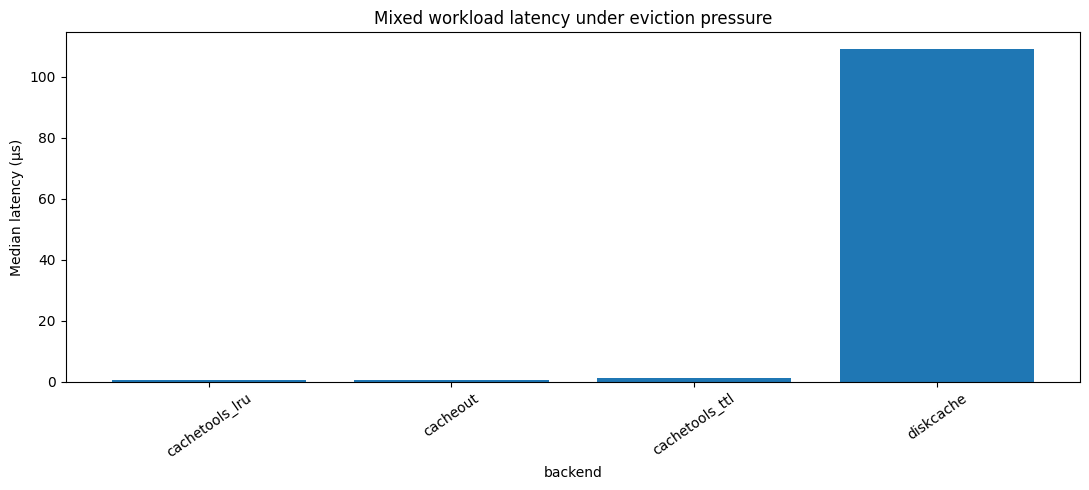

Saved figure: benchmark_results/figures/application_cache_mixed_workload_median_latency.png


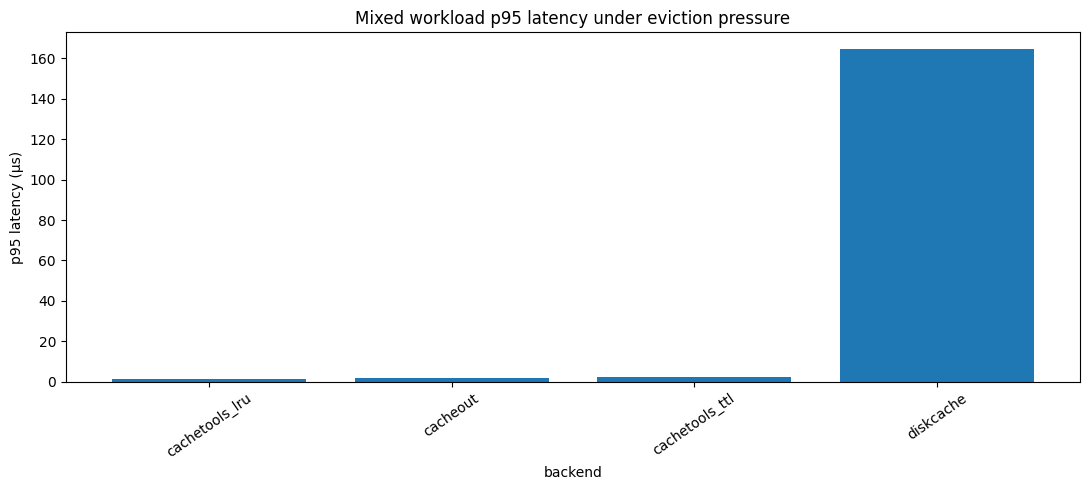

Saved figure: benchmark_results/figures/application_cache_mixed_workload_p95_latency.png


In [9]:
plot_df = mixed_summary[mixed_summary["payload"] == "medium_series"]
barplot(
    plot_df,
    x="backend",
    y="median_us",
    title="Mixed workload latency under eviction pressure",
    ylabel="Median latency (µs)",
    filename="application_cache_mixed_workload_median_latency.png",
)

barplot(
    plot_df,
    x="backend",
    y="p95_us",
    title="Mixed workload p95 latency under eviction pressure",
    ylabel="p95 latency (µs)",
    filename="application_cache_mixed_workload_p95_latency.png",
)


## TTL expiration benchmark

TTL behavior matters for API data freshness. This benchmark measures whether expiration works correctly and the latency cost after expiration.


In [10]:
def benchmark_ttl_expiration(
    backend_kind: str,
    n_keys: int = 256,
    ttl: float = 0.25,
    sleep_factor: float = 1.5,
    n_runs: int = 5,
) -> list[dict[str, Any]]:
    rows = []
    keys = make_workload_keys(n_keys)
    payload = make_fred_like_payload("DGS10", PAYLOAD_SIZES["small_metadata"])

    for run in range(n_runs):
        with managed_backend(backend_kind, maxsize=CACHE_MAXSIZE, ttl=ttl) as cache:
            for key in keys:
                cache.set(key, payload)

            pre_expiry_hits = 0
            for key in keys:
                if cache.get(key, _MISSING) is not _MISSING:
                    pre_expiry_hits += 1

            time.sleep(ttl * sleep_factor)

            latencies = []
            post_expiry_hits = 0
            for key in keys:
                t0 = now_ns()
                value = cache.get(key, _MISSING)
                latencies.append(now_ns() - t0)
                if value is not _MISSING:
                    post_expiry_hits += 1

            rows.append({
                "backend": backend_kind,
                "run": run,
                "ttl_seconds": ttl,
                "n_keys": n_keys,
                "pre_expiry_hit_rate": pre_expiry_hits / n_keys,
                "post_expiry_hit_rate": post_expiry_hits / n_keys,
                **summarize_latencies(latencies),
            })
    return rows


ttl_backends = [b for b in APPLICATION_BACKENDS if b in {"cachetools_ttl", "diskcache", "cacheout"}]
ttl_rows = []
for backend in ttl_backends:
    print(f"Running TTL benchmark: backend={backend}")
    ttl_rows.extend(benchmark_ttl_expiration(backend))

ttl_df = pd.DataFrame(ttl_rows)
ttl_df.to_csv(RESULTS_DIR / "application_cache_ttl_expiration.csv", index=False)
ttl_summary = ttl_df.groupby("backend", as_index=False).agg(
    pre_expiry_hit_rate=("pre_expiry_hit_rate", "mean"),
    post_expiry_hit_rate=("post_expiry_hit_rate", "mean"),
    median_us=("median_us", "mean"),
    p95_us=("p95_us", "mean"),
)
ttl_summary


Running TTL benchmark: backend=cachetools_ttl
Running TTL benchmark: backend=diskcache
Running TTL benchmark: backend=cacheout


,backend,pre_expiry_hit_rate,post_expiry_hit_rate,median_us,p95_us
0,cacheout,1.0,0.0,1.2916,2.0332
1,cachetools_ttl,1.0,0.0,0.8000,1.2000
2,diskcache,1.0,0.0,23.1542,39.3918


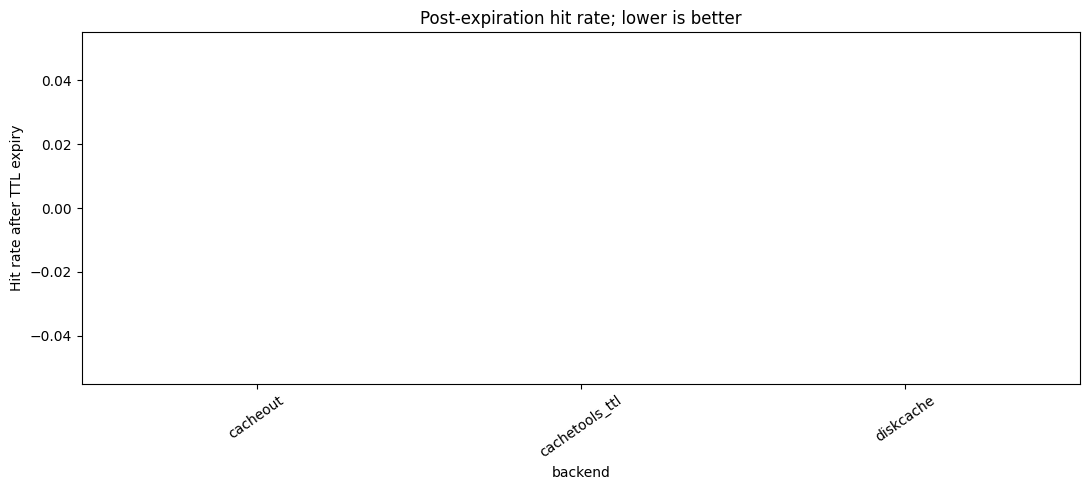

Saved figure: benchmark_results/figures/application_cache_ttl_post_expiry_hit_rate.png


In [11]:
if not ttl_summary.empty:
    barplot(
        ttl_summary,
        x="backend",
        y="post_expiry_hit_rate",
        title="Post-expiration hit rate; lower is better",
        ylabel="Hit rate after TTL expiry",
        filename="application_cache_ttl_post_expiry_hit_rate.png",
        sort=False,
    )


## Threaded access benchmark

`fedfred` may use caching under concurrent sync requests or parallel workflows. This benchmark uses repeated threaded reads/writes against the same backend instance.


In [12]:
def benchmark_threaded_workload(
    backend_kind: str,
    n_tasks: int = 20_000,
    n_keys: int = 1_000,
    workers: int = THREAD_WORKERS,
    n_runs: int = 5,
) -> list[dict[str, Any]]:
    rows = []
    keys = make_workload_keys(n_keys)
    payload = make_fred_like_payload("DGS10", PAYLOAD_SIZES["small_metadata"])

    def one_op(cache: CacheBackend, i: int) -> int:
        key = keys[i % n_keys]
        t0 = now_ns()
        value = cache.get(key, _MISSING)
        if value is _MISSING:
            cache.set(key, payload)
        return now_ns() - t0

    for run in range(n_runs):
        with managed_backend(backend_kind, maxsize=CACHE_MAXSIZE) as cache:
            t_start = perf_counter()
            latencies = []
            with ThreadPoolExecutor(max_workers=workers) as executor:
                futures = [executor.submit(one_op, cache, i) for i in range(n_tasks)]
                for future in as_completed(futures):
                    latencies.append(future.result())
            elapsed = perf_counter() - t_start

        rows.append({
            "backend": backend_kind,
            "run": run,
            "n_tasks": n_tasks,
            "workers": workers,
            "elapsed_s": elapsed,
            "throughput_ops_s": n_tasks / elapsed,
            **summarize_latencies(latencies),
        })
    return rows


thread_rows = []
for backend in APPLICATION_BACKENDS:
    print(f"Running threaded benchmark: backend={backend}")
    thread_rows.extend(benchmark_threaded_workload(backend))

thread_df = pd.DataFrame(thread_rows)
thread_df.to_csv(RESULTS_DIR / "application_cache_threaded.csv", index=False)
thread_summary = thread_df.groupby("backend", as_index=False).agg(
    throughput_ops_s=("throughput_ops_s", "mean"),
    median_us=("median_us", "mean"),
    p95_us=("p95_us", "mean"),
)
thread_summary


Running threaded benchmark: backend=cachetools_lru
Running threaded benchmark: backend=cachetools_ttl
Running threaded benchmark: backend=diskcache
Running threaded benchmark: backend=cacheout


,backend,throughput_ops_s,median_us,p95_us
0,cacheout,75174.545650,2.7416,146.5418
1,cachetools_lru,77314.659951,1.7500,48.4498
2,cachetools_ttl,64281.487752,3.8916,16.2670
3,diskcache,7424.715624,869.3540,2015.5666


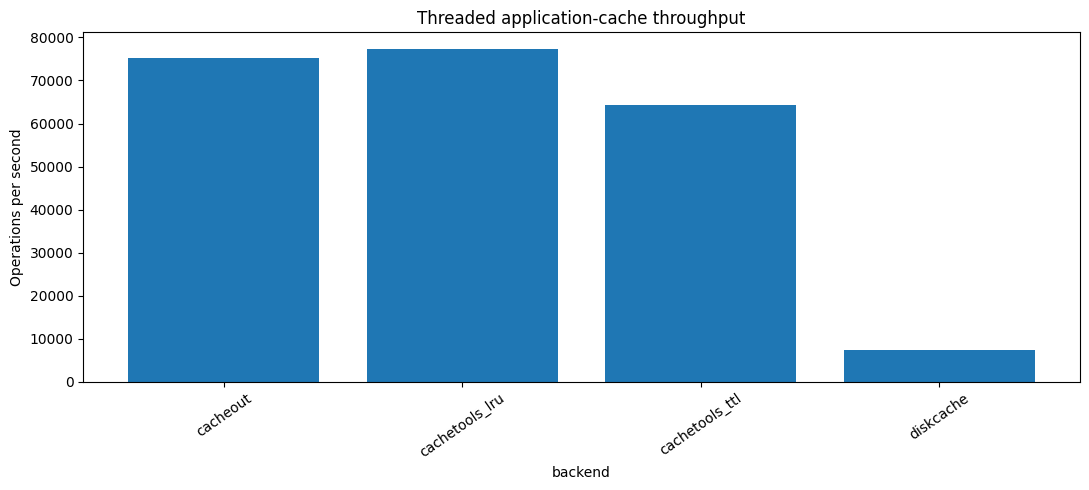

Saved figure: benchmark_results/figures/application_cache_threaded_throughput.png


In [13]:
barplot(
    thread_summary,
    x="backend",
    y="throughput_ops_s",
    title="Threaded application-cache throughput",
    ylabel="Operations per second",
    filename="application_cache_threaded_throughput.png",
    sort=False,
)


## Persistence benchmark

This specifically tests the argument for `diskcache` as an optional persistent notebook/research cache.


In [14]:
def benchmark_diskcache_persistence(n_keys: int = 512) -> pd.DataFrame:
    if diskcache is None:
        return pd.DataFrame()

    directory = Path(tempfile.mkdtemp(prefix="fedfred_persistence_test_"))
    keys = make_workload_keys(n_keys)
    payload = make_fred_like_payload("DGS10", PAYLOAD_SIZES["medium_series"])

    try:
        cache1 = diskcache.Cache(str(directory))
        for key in keys:
            cache1.set(key, payload)
        cache1.close()

        cache2 = diskcache.Cache(str(directory))
        latencies = []
        hits = 0
        for key in keys:
            t0 = now_ns()
            value = cache2.get(key, default=_MISSING)
            latencies.append(now_ns() - t0)
            hits += int(value is not _MISSING)
        cache2.close()

        return pd.DataFrame([{
            "backend": "diskcache",
            "n_keys": n_keys,
            "restart_hit_rate": hits / n_keys,
            **summarize_latencies(latencies),
        }])
    finally:
        shutil.rmtree(directory, ignore_errors=True)


persistence_df = benchmark_diskcache_persistence()
persistence_df.to_csv(RESULTS_DIR / "diskcache_persistence.csv", index=False)
persistence_df


,backend,n_keys,restart_hit_rate,mean_us,median_us,p95_us,min_us,max_us
0,diskcache,512,1.0,121.109463,115.4795,161.458,109.0,653.125


# Transport-level HTTP caching

This section compares:

- uncached `httpx`
- uncached `requests`
- `hishel` with `httpx`
- `requests-cache` with `requests`

The local server returns cacheable JSON responses with deterministic payloads.


In [15]:
class BenchmarkHTTPState:
    request_counts: Counter[str] = Counter()
    lock = threading.Lock()
    artificial_delay_s = 0.01

    @classmethod
    def reset(cls) -> None:
        with cls.lock:
            cls.request_counts.clear()

    @classmethod
    def increment(cls, key: str) -> int:
        with cls.lock:
            cls.request_counts[key] += 1
            return cls.request_counts[key]

    @classmethod
    def total_origin_hits(cls) -> int:
        with cls.lock:
            return sum(cls.request_counts.values())


class FredLikeHandler(BaseHTTPRequestHandler):
    protocol_version = "HTTP/1.1"

    def do_GET(self) -> None:
        parsed = urllib.parse.urlparse(self.path)
        query = urllib.parse.parse_qs(parsed.query)
        series_id = query.get("series_id", ["DGS10"])[0]
        n_obs = int(query.get("n_obs", ["100"])[0])

        cache_key = parsed.path + "?" + urllib.parse.urlencode(sorted((k, v[0]) for k, v in query.items()))
        count = BenchmarkHTTPState.increment(cache_key)
        time.sleep(BenchmarkHTTPState.artificial_delay_s)

        body_obj = make_fred_like_payload(series_id=series_id, n_obs=n_obs)
        body = json.dumps(body_obj).encode("utf-8")
        etag = hashlib.sha256(body).hexdigest()

        if self.headers.get("If-None-Match") == etag:
            self.send_response(304)
            self.send_header("ETag", etag)
            self.send_header("Cache-Control", "public, max-age=3600")
            self.send_header("Content-Length", "0")
            self.end_headers()
            return

        self.send_response(200)
        self.send_header("Content-Type", "application/json")
        self.send_header("Content-Length", str(len(body)))
        self.send_header("Cache-Control", "public, max-age=3600")
        self.send_header("ETag", etag)
        self.end_headers()
        self.wfile.write(body)

    def log_message(self, format: str, *args: Any) -> None:
        return


@contextlib.contextmanager
def run_local_http_server(delay_s: float = 0.01) -> Iterator[str]:
    BenchmarkHTTPState.artificial_delay_s = delay_s
    BenchmarkHTTPState.reset()
    server = ThreadingHTTPServer(("127.0.0.1", 0), FredLikeHandler)
    host, port = server.server_address
    thread = threading.Thread(target=server.serve_forever, daemon=True)
    thread.start()
    try:
        yield f"http://{host}:{port}"
    finally:
        server.shutdown()
        server.server_close()
        thread.join(timeout=2)


def make_urls(base_url: str, n_unique: int, n_obs: int = 100) -> list[str]:
    series_ids = ["DGS10", "UNRATE", "CPIAUCSL", "FEDFUNDS", "PAYEMS", "GDPC1", "PCE", "INDPRO", "M2SL", "HOUST"]
    urls = []
    for i in range(n_unique):
        params = urllib.parse.urlencode({
            "series_id": series_ids[i % len(series_ids)],
            "n_obs": n_obs,
            "vintage": f"{2000 + (i % 20)}-01-01",
        })
        urls.append(f"{base_url}/fred/series/observations?{params}")
    return urls


## Transport client factories

The `hishel` API has changed across versions. The helper below attempts the common sync `httpx` client integration patterns. If the installed version does not expose a compatible sync client, the notebook skips that benchmark row rather than failing the entire notebook.


In [16]:
@contextlib.contextmanager
def http_client(kind: str, cache_dir: Path | None = None):
    if kind == "httpx_uncached":
        if httpx is None:
            raise ImportError("httpx is not installed")
        with httpx.Client(timeout=30.0) as client:
            yield lambda url: client.get(url)
        return

    if kind == "requests_uncached":
        if requests is None:
            raise ImportError("requests is not installed")
        session = requests.Session()
        try:
            yield lambda url: session.get(url, timeout=30.0)
        finally:
            session.close()
        return

    if kind == "requests_cache":
        if requests_cache is None:
            raise ImportError("requests-cache is not installed")
        if cache_dir is None:
            cache_dir = Path(tempfile.mkdtemp(prefix="requests_cache_"))
        session = requests_cache.CachedSession(
            cache_name=str(cache_dir / "requests_cache"),
            backend="sqlite",
            expire_after=3600,
            allowable_methods=("GET",),
        )
        try:
            yield lambda url: session.get(url, timeout=30.0)
        finally:
            session.close()
        return

    if kind == "hishel":
        if hishel is None or httpx is None:
            raise ImportError("hishel and httpx are required")
        if cache_dir is None:
            cache_dir = Path(tempfile.mkdtemp(prefix="hishel_cache_"))

        # Common path for modern hishel versions.
        try:
            import hishel.httpx as hishel_httpx
            if hasattr(hishel_httpx, "CacheClient"):
                client = hishel_httpx.CacheClient(timeout=30.0)
                try:
                    yield lambda url: client.get(url)
                finally:
                    client.close()
                return
        except Exception:
            pass

        # Lower-level transport path used by several hishel versions.
        try:
            controller = hishel.Controller()
            storage = hishel.FileStorage(base_path=cache_dir)
            transport = hishel.CacheTransport(
                transport=httpx.HTTPTransport(),
                controller=controller,
                storage=storage,
            )
            client = httpx.Client(transport=transport, timeout=30.0)
            try:
                yield lambda url: client.get(url)
            finally:
                client.close()
            return
        except Exception as exc:
            raise RuntimeError(f"Could not construct a compatible hishel sync client: {exc}") from exc

    raise ValueError(f"Unknown HTTP client kind: {kind}")


TRANSPORT_CLIENTS = [
    kind for kind, available in [
        ("httpx_uncached", httpx is not None),
        ("requests_uncached", requests is not None),
        ("hishel", hishel is not None and httpx is not None),
        ("requests_cache", requests_cache is not None and requests is not None),
    ] if available
]

TRANSPORT_CLIENTS


['httpx_uncached', 'requests_uncached', 'hishel', 'requests_cache']

In [17]:
def response_from_cache(response: Any) -> bool | None:
    # requests-cache sets this attribute.
    if hasattr(response, "from_cache"):
        return bool(response.from_cache)
    # hishel/httpx versions may expose extensions. Keep this defensive.
    extensions = getattr(response, "extensions", {}) or {}
    for key in ("from_cache", "hishel_from_cache", "cached"):
        if key in extensions:
            return bool(extensions[key])
    return None


def benchmark_transport_client(
    client_kind: str,
    n_unique: int = 50,
    repeats: int = 4,
    n_obs: int = 100,
    delay_s: float = 0.01,
    n_runs: int = 5,
) -> list[dict[str, Any]]:
    rows = []
    for run in range(n_runs):
        with run_local_http_server(delay_s=delay_s) as base_url:
            urls = make_urls(base_url, n_unique=n_unique, n_obs=n_obs)
            request_sequence = urls * repeats
            random.Random(RANDOM_SEED + run).shuffle(request_sequence)
            cache_dir = Path(tempfile.mkdtemp(prefix=f"{client_kind}_"))

            try:
                with http_client(client_kind, cache_dir=cache_dir) as get:
                    latencies = []
                    cache_flags: list[bool] = []
                    t_start = perf_counter()
                    for url in request_sequence:
                        t0 = now_ns()
                        response = get(url)
                        _ = response.json()
                        latencies.append(now_ns() - t0)
                        flag = response_from_cache(response)
                        if flag is not None:
                            cache_flags.append(flag)
                    elapsed_s = perf_counter() - t_start
            except Exception as exc:
                rows.append({
                    "client": client_kind,
                    "run": run,
                    "error": repr(exc),
                    "n_unique": n_unique,
                    "repeats": repeats,
                    "n_requests": len(request_sequence),
                })
                continue
            finally:
                shutil.rmtree(cache_dir, ignore_errors=True)

            total_origin_hits = BenchmarkHTTPState.total_origin_hits()
            rows.append({
                "client": client_kind,
                "run": run,
                "error": None,
                "n_unique": n_unique,
                "repeats": repeats,
                "n_requests": len(request_sequence),
                "origin_hits": total_origin_hits,
                "origin_hit_rate": total_origin_hits / len(request_sequence),
                "observed_cache_hit_rate": None if not cache_flags else sum(cache_flags) / len(cache_flags),
                "elapsed_s": elapsed_s,
                "requests_per_s": len(request_sequence) / elapsed_s,
                **summarize_latencies(latencies),
            })
    return rows


transport_rows = []
for client in TRANSPORT_CLIENTS:
    print(f"Running transport benchmark: client={client}")
    transport_rows.extend(benchmark_transport_client(client))

transport_df = pd.DataFrame(transport_rows)
transport_df.to_csv(RESULTS_DIR / "transport_cache_benchmarks.csv", index=False)
transport_df


Running transport benchmark: client=httpx_uncached
Running transport benchmark: client=requests_uncached
Running transport benchmark: client=hishel
Running transport benchmark: client=requests_cache


,client,run,error,n_unique,repeats,n_requests,origin_hits,origin_hit_rate,observed_cache_hit_rate,elapsed_s,requests_per_s,mean_us,median_us,p95_us,min_us,max_us
0,httpx_uncached,0,NaN,50,4,200,200.0,1.0,NaN,2.624963,76.191545,13123.182535,13155.5000,13807.667,10678.750,30570.541
1,httpx_uncached,1,NaN,50,4,200,200.0,1.0,NaN,2.690957,74.323013,13452.558260,13264.3335,16832.500,10934.083,32521.000
2,httpx_uncached,2,NaN,50,4,200,200.0,1.0,NaN,2.584704,77.378309,12921.232270,13209.1250,13898.917,10976.042,17691.708
3,httpx_uncached,3,NaN,50,4,200,200.0,1.0,NaN,2.743158,72.908663,13712.931420,13295.7910,21646.250,10796.709,34110.542
4,httpx_uncached,4,NaN,50,4,200,200.0,1.0,NaN,2.564108,77.999843,12818.847105,13178.6460,13566.917,10713.250,14152.041
5,requests_uncached,0,NaN,50,4,200,200.0,1.0,NaN,2.901392,68.932440,14503.220000,13757.2710,21431.791,11207.750,58143.083
6,requests_uncached,1,NaN,50,4,200,200.0,1.0,NaN,2.775970,72.046875,13877.460025,13773.2710,14149.083,11140.125,32373.792
7,requests_uncached,2,NaN,50,4,200,200.0,1.0,NaN,2.745268,72.852631,13724.352495,13655.5835,14500.500,11198.750,32296.250
8,requests_uncached,3,NaN,50,4,200,200.0,1.0,NaN,2.630465,76.032175,13150.527945,13456.4165,13967.417,10909.875,14514.917
9,requests_uncached,4,NaN,50,4,200,200.0,1.0,NaN,2.653418,75.374490,13265.230845,13547.7705,13988.542,11030.083,18490.291


In [18]:
transport_ok = transport_df[transport_df["error"].isna()].copy()
transport_summary = transport_ok.groupby("client", as_index=False).agg(
    median_us=("median_us", "mean"),
    p95_us=("p95_us", "mean"),
    origin_hits=("origin_hits", "mean"),
    origin_hit_rate=("origin_hit_rate", "mean"),
    observed_cache_hit_rate=("observed_cache_hit_rate", "mean"),
    requests_per_s=("requests_per_s", "mean"),
)
transport_summary.to_csv(RESULTS_DIR / "transport_cache_summary.csv", index=False)
transport_summary


,client,median_us,p95_us,origin_hits,origin_hit_rate,observed_cache_hit_rate,requests_per_s
0,httpx_uncached,13220.6791,15950.4502,200.0,1.0,NaN,75.760275
1,requests_cache,480.3335,14522.0250,20.0,0.1,0.9,509.431747
2,requests_uncached,13638.0625,15607.4666,200.0,1.0,NaN,73.047722


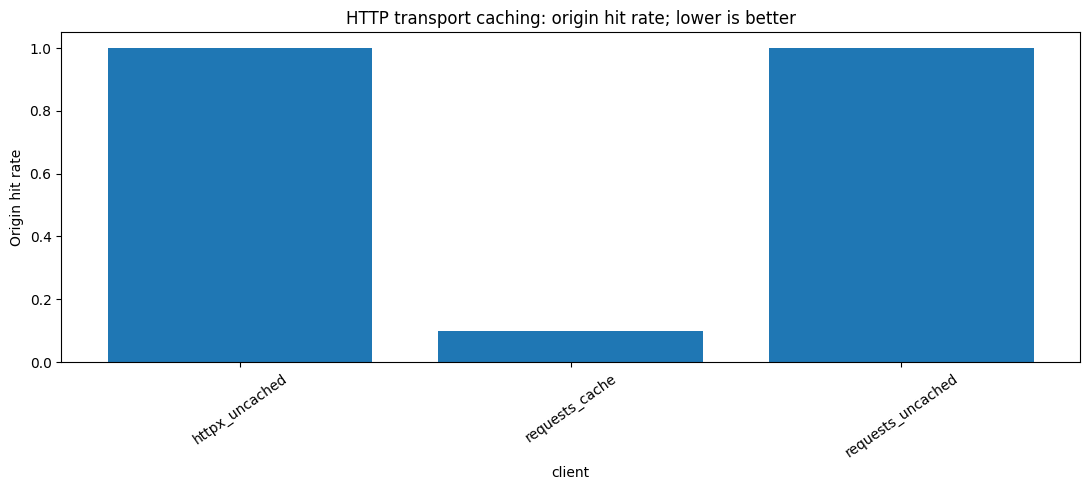

Saved figure: benchmark_results/figures/transport_cache_origin_hit_rate.png


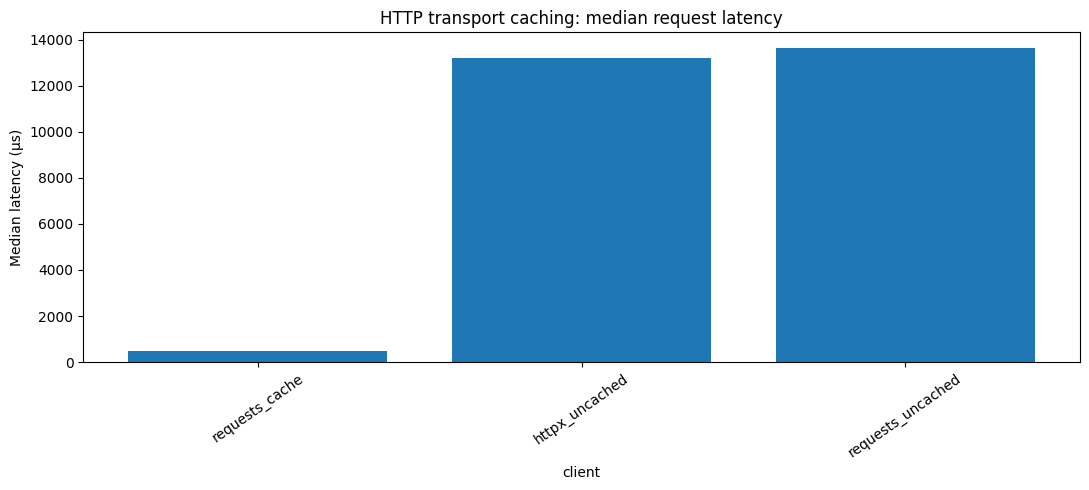

Saved figure: benchmark_results/figures/transport_cache_median_latency.png


In [19]:
if not transport_summary.empty:
    barplot(
        transport_summary,
        x="client",
        y="origin_hit_rate",
        title="HTTP transport caching: origin hit rate; lower is better",
        ylabel="Origin hit rate",
        filename="transport_cache_origin_hit_rate.png",
        sort=False,
    )
    barplot(
        transport_summary,
        x="client",
        y="median_us",
        title="HTTP transport caching: median request latency",
        ylabel="Median latency (µs)",
        filename="transport_cache_median_latency.png",
    )


# Cross-layer comparison

This section compares application-level response caching against transport-level caching.

Application-level caching wraps an uncached `httpx` request. If a key exists in the application cache, the HTTP request is skipped entirely. This approximates a `fedfred` request cache implemented above the transport layer.


In [20]:
class AppCachedHTTPClient:
    def __init__(self, backend: CacheBackend, base_url: str) -> None:
        if httpx is None:
            raise ImportError("httpx is required")
        self.backend = backend
        self.base_url = base_url
        self.client = httpx.Client(timeout=30.0)

    def close(self) -> None:
        self.client.close()

    def get_series(self, series_id: str, n_obs: int, vintage: str) -> dict[str, Any]:
        params = {"series_id": series_id, "n_obs": n_obs, "vintage": vintage}
        key = make_cache_key("fred", "series/observations", params)
        cached = self.backend.get(key, _MISSING)
        if cached is not _MISSING:
            return cached
        url = f"{self.base_url}/fred/series/observations?{urllib.parse.urlencode(params)}"
        response = self.client.get(url)
        response.raise_for_status()
        payload = response.json()
        self.backend.set(key, payload)
        return payload


def benchmark_app_cached_http(
    backend_kind: str,
    n_unique: int = 50,
    repeats: int = 4,
    n_obs: int = 100,
    delay_s: float = 0.01,
    n_runs: int = 5,
) -> list[dict[str, Any]]:
    rows = []
    series_ids = ["DGS10", "UNRATE", "CPIAUCSL", "FEDFUNDS", "PAYEMS", "GDPC1", "PCE", "INDPRO", "M2SL", "HOUST"]
    request_params = [
        (series_ids[i % len(series_ids)], n_obs, f"{2000 + (i % 20)}-01-01")
        for i in range(n_unique)
    ] * repeats

    for run in range(n_runs):
        random.Random(RANDOM_SEED + run).shuffle(request_params)
        with run_local_http_server(delay_s=delay_s) as base_url:
            with managed_backend(backend_kind, maxsize=CACHE_MAXSIZE) as backend:
                client = AppCachedHTTPClient(backend, base_url)
                latencies = []
                t_start = perf_counter()
                try:
                    for series_id, n, vintage in request_params:
                        t0 = now_ns()
                        _ = client.get_series(series_id, n, vintage)
                        latencies.append(now_ns() - t0)
                    elapsed_s = perf_counter() - t_start
                finally:
                    client.close()

                origin_hits = BenchmarkHTTPState.total_origin_hits()
                rows.append({
                    "layer": "application_cache",
                    "client_or_backend": backend_kind,
                    "run": run,
                    "n_unique": n_unique,
                    "repeats": repeats,
                    "n_requests": len(request_params),
                    "origin_hits": origin_hits,
                    "origin_hit_rate": origin_hits / len(request_params),
                    "elapsed_s": elapsed_s,
                    "requests_per_s": len(request_params) / elapsed_s,
                    **summarize_latencies(latencies),
                })
    return rows


def benchmark_transport_for_cross_layer(
    client_kind: str,
    n_unique: int = 50,
    repeats: int = 4,
    n_obs: int = 100,
    delay_s: float = 0.01,
    n_runs: int = 5,
) -> list[dict[str, Any]]:
    rows = benchmark_transport_client(
        client_kind=client_kind,
        n_unique=n_unique,
        repeats=repeats,
        n_obs=n_obs,
        delay_s=delay_s,
        n_runs=n_runs,
    )
    out = []
    for row in rows:
        out.append({
            "layer": "transport_cache" if client_kind in {"hishel", "requests_cache"} else "transport_uncached",
            "client_or_backend": client_kind,
            **{k: v for k, v in row.items() if k not in {"client"}},
        })
    return out


cross_rows = []
for backend in APPLICATION_BACKENDS:
    print(f"Running cross-layer application cache: backend={backend}")
    cross_rows.extend(benchmark_app_cached_http(backend))

for client in TRANSPORT_CLIENTS:
    print(f"Running cross-layer transport client: client={client}")
    cross_rows.extend(benchmark_transport_for_cross_layer(client))

cross_df = pd.DataFrame(cross_rows)
cross_df.to_csv(RESULTS_DIR / "cross_layer_cache_benchmarks.csv", index=False)
cross_df.head()


Running cross-layer application cache: backend=cachetools_lru
Running cross-layer application cache: backend=cachetools_ttl
Running cross-layer application cache: backend=diskcache
Running cross-layer application cache: backend=cacheout
Running cross-layer transport client: client=httpx_uncached
Running cross-layer transport client: client=requests_uncached
Running cross-layer transport client: client=hishel
Running cross-layer transport client: client=requests_cache


,layer,client_or_backend,run,n_unique,repeats,n_requests,origin_hits,origin_hit_rate,elapsed_s,requests_per_s,mean_us,median_us,p95_us,min_us,max_us,error,observed_cache_hit_rate
0,application_cache,cachetools_lru,0,50,4,200,20.0,0.1,0.272328,734.408734,1361.393545,1.042,13447.959,0.916,23307.208,NaN,NaN
1,application_cache,cachetools_lru,1,50,4,200,20.0,0.1,0.255158,783.827162,1275.565160,0.917,13081.417,0.833,13681.750,NaN,NaN
2,application_cache,cachetools_lru,2,50,4,200,20.0,0.1,0.258763,772.906908,1293.585990,1.042,13278.042,0.875,14015.709,NaN,NaN
3,application_cache,cachetools_lru,3,50,4,200,20.0,0.1,0.316023,632.864578,1579.874945,1.042,13478.709,0.916,26316.083,NaN,NaN
4,application_cache,cachetools_lru,4,50,4,200,20.0,0.1,0.251085,796.543003,1255.181675,1.083,12854.666,0.875,13844.500,NaN,NaN


In [21]:
cross_ok = cross_df[cross_df.get("error").isna() if "error" in cross_df.columns else [True] * len(cross_df)].copy()
cross_summary = cross_ok.groupby(["layer", "client_or_backend"], as_index=False).agg(
    median_us=("median_us", "mean"),
    p95_us=("p95_us", "mean"),
    origin_hit_rate=("origin_hit_rate", "mean"),
    requests_per_s=("requests_per_s", "mean"),
    origin_hits=("origin_hits", "mean"),
)
cross_summary.to_csv(RESULTS_DIR / "cross_layer_cache_summary.csv", index=False)
cross_summary


,layer,client_or_backend,median_us,p95_us,origin_hit_rate,requests_per_s,origin_hits
0,application_cache,cacheout,0.9918,13227.9166,0.1,767.291683,20.0
1,application_cache,cachetools_lru,1.0252,13228.1586,0.1,744.110077,20.0
2,application_cache,cachetools_ttl,1.6126,13272.6748,0.1,767.285241,20.0
3,application_cache,diskcache,44.9959,13638.9250,0.1,713.663034,20.0
4,transport_cache,requests_cache,518.6791,14451.4498,0.1,496.122820,20.0
5,transport_uncached,httpx_uncached,13196.9040,13649.7998,1.0,76.727861,200.0
6,transport_uncached,requests_uncached,13492.4292,13962.2748,1.0,75.728643,200.0


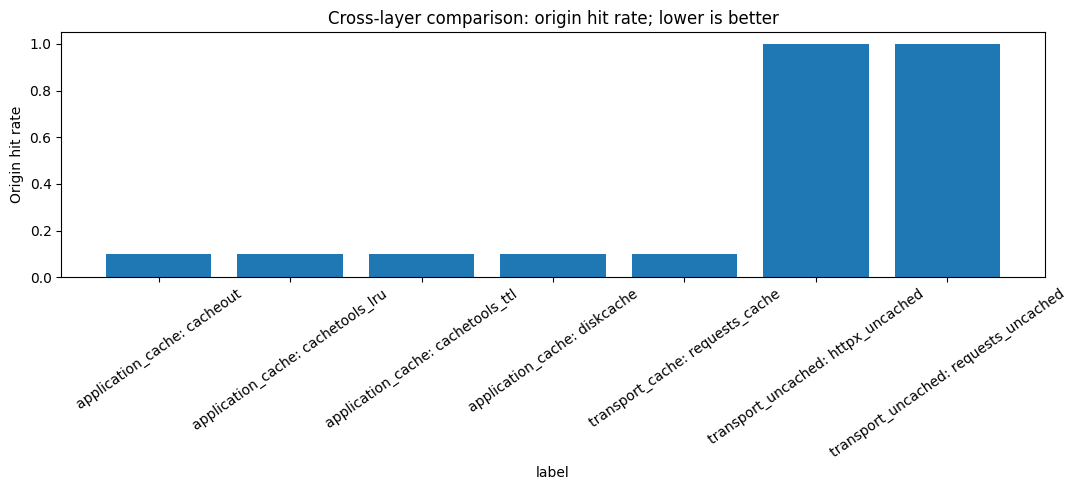

Saved figure: benchmark_results/figures/cross_layer_origin_hit_rate.png


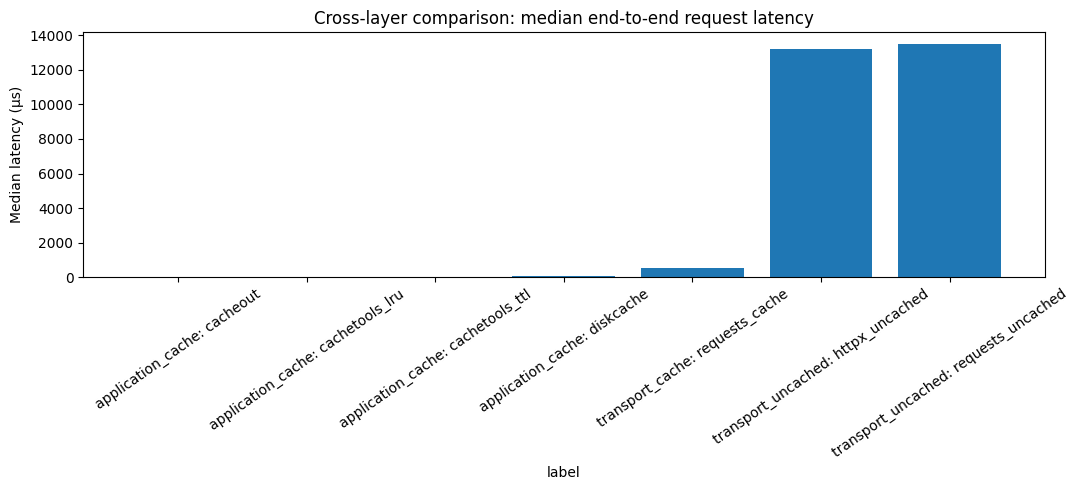

Saved figure: benchmark_results/figures/cross_layer_median_latency.png


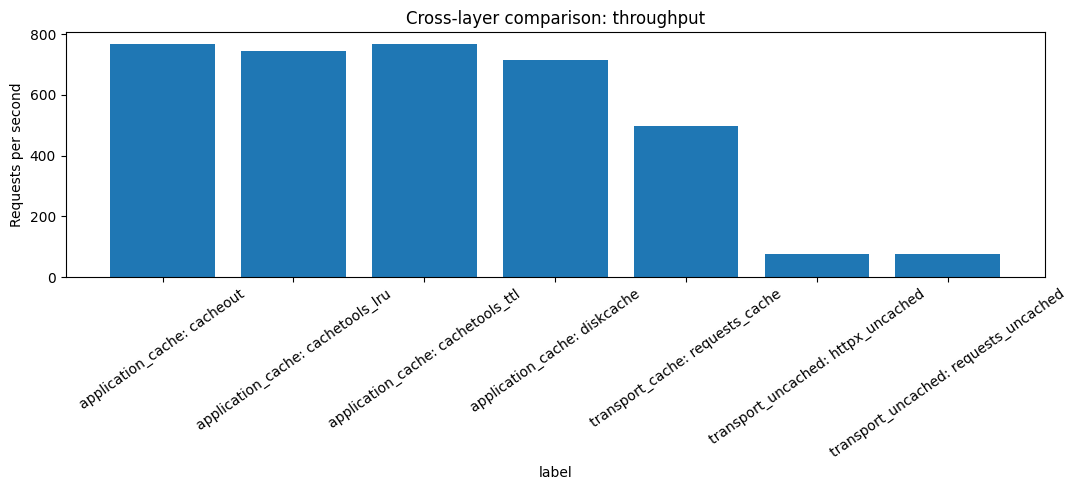

Saved figure: benchmark_results/figures/cross_layer_throughput.png


In [22]:
if not cross_summary.empty:
    cross_summary["label"] = cross_summary["layer"] + ": " + cross_summary["client_or_backend"]
    barplot(
        cross_summary,
        x="label",
        y="origin_hit_rate",
        title="Cross-layer comparison: origin hit rate; lower is better",
        ylabel="Origin hit rate",
        filename="cross_layer_origin_hit_rate.png",
        sort=False,
    )
    barplot(
        cross_summary,
        x="label",
        y="median_us",
        title="Cross-layer comparison: median end-to-end request latency",
        ylabel="Median latency (µs)",
        filename="cross_layer_median_latency.png",
    )
    barplot(
        cross_summary,
        x="label",
        y="requests_per_s",
        title="Cross-layer comparison: throughput",
        ylabel="Requests per second",
        filename="cross_layer_throughput.png",
        sort=False,
    )


# Final decision table

This cell generates a compact decision table from the benchmark outputs.

Interpretation rule:

- For default `fedfred` caching, prioritize **fast hit latency**, **low overhead**, **simple dependency surface**, and **safe integration**.
- For optional research/notebook caching, prioritize **persistence**, **restart hit rate**, and **large-payload behavior**.
- For transport caching, prioritize **HTTP semantics** and **origin-hit reduction**, not just raw speed.


In [23]:
def build_decision_table() -> pd.DataFrame:
    rows = []

    if "micro_summary" in globals() and not micro_summary.empty:
        hit_medium = micro_summary[(micro_summary["payload"] == "medium_series") & (micro_summary["operation"] == "hit")]
        for _, row in hit_medium.iterrows():
            rows.append({
                "candidate": row["backend"],
                "layer": "application",
                "main_strength": "in-process request-result cache",
                "median_hit_us_medium_payload": row["median_us"],
                "origin_hit_rate": None,
                "persistence": "yes" if row["backend"] == "diskcache" else "no",
                "recommended_role": (
                    "optional persistent research/notebook cache" if row["backend"] == "diskcache"
                    else "default or experimental in-memory backend"
                ),
            })

    if "transport_summary" in globals() and not transport_summary.empty:
        for _, row in transport_summary.iterrows():
            rows.append({
                "candidate": row["client"],
                "layer": "transport",
                "main_strength": "HTTP response caching semantics",
                "median_hit_us_medium_payload": row["median_us"],
                "origin_hit_rate": row["origin_hit_rate"],
                "persistence": "depends on configured storage",
                "recommended_role": (
                    "httpx transport-cache candidate" if row["client"] == "hishel"
                    else "requests transport-cache reference" if row["client"] == "requests_cache"
                    else "uncached baseline"
                ),
            })

    return pd.DataFrame(rows)


decision_df = build_decision_table()
decision_df.to_csv(RESULTS_DIR / "cache_backend_decision_table.csv", index=False)
decision_df


,candidate,layer,main_strength,median_hit_us_medium_payload,origin_hit_rate,persistence,recommended_role
0,cacheout,application,in-process request-result cache,0.7080,NaN,no,default or experimental in-memory backend
1,cachetools_lru,application,in-process request-result cache,0.7248,NaN,no,default or experimental in-memory backend
2,cachetools_ttl,application,in-process request-result cache,1.3332,NaN,no,default or experimental in-memory backend
3,diskcache,application,in-process request-result cache,113.1168,NaN,yes,optional persistent research/notebook cache
4,httpx_uncached,transport,HTTP response caching semantics,13220.6791,1.0,depends on configured storage,uncached baseline
5,requests_cache,transport,HTTP response caching semantics,480.3335,0.1,depends on configured storage,requests transport-cache reference
6,requests_uncached,transport,HTTP response caching semantics,13638.0625,1.0,depends on configured storage,uncached baseline
